<a href="https://colab.research.google.com/github/sasurasa/Lin/blob/main/Lin120726SS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
file_path = "/content/apri.xlsx"
sheet_name = "cleanup (2)"
df = pd.read_excel(file_path, sheet_name=sheet_name)

In [ ]:
apri_columns = [
    "preapri",
    "immapri",
    "d7apri",
    "m1apri",
    "m4apri",
    "m5apri",
    "m6apri",
    "y2apri",
    "y5apri"
]

In [ ]:
time_labels = [
    "Pre-HPE",
    "Immediate\npost-op",
    "Day 7",
    "Month 1",
    "Month 4",
    "Month 5",
    "Month 6",
    "Year 2",
    "Year 5"
]

In [ ]:
#Data preparation
for column in apri_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")
df[apri_columns] = df[apri_columns].mask(df[apri_columns] < 0)

In [ ]:
summary = pd.DataFrame({
    "column": apri_columns,
    "time": time_labels,
    "n": [df[column].count() for column in apri_columns],
    "mean": [df[column].mean() for column in apri_columns],
    "sd": [df[column].std(ddof=1) for column in apri_columns],
    "median": [df[column].median() for column in apri_columns],
    "q1": [df[column].quantile(0.25) for column in apri_columns],
    "q3": [df[column].quantile(0.75) for column in apri_columns]
})

summary["lower_sd"] = np.maximum(summary["mean"] - summary["sd"], 0)
summary["upper_sd"] = summary["mean"] + summary["sd"]

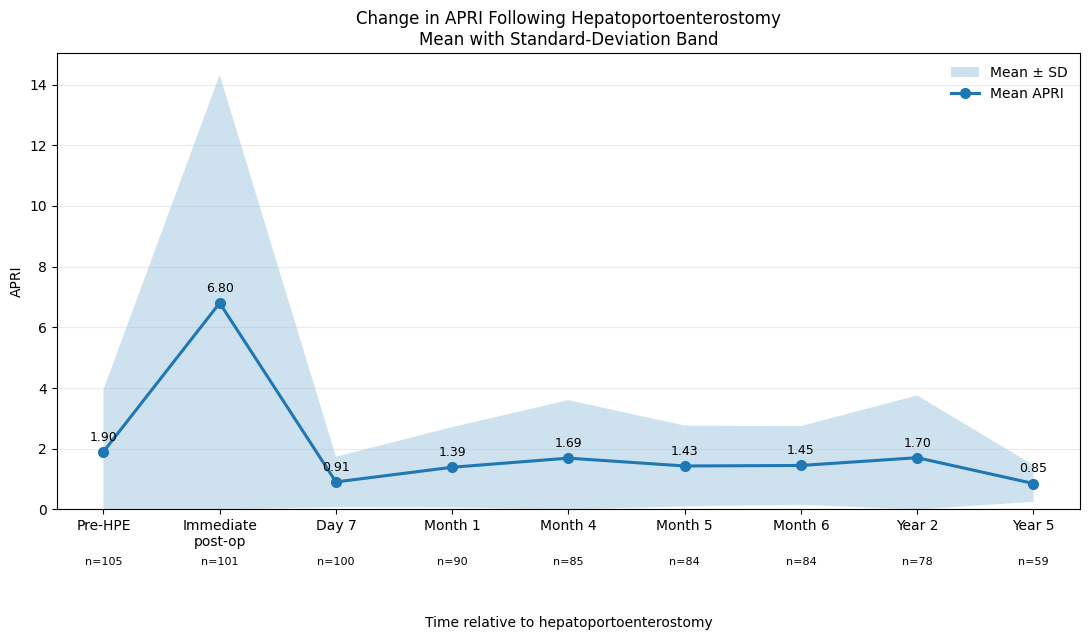

In [ ]:
x = np.arange(len(summary))

fig, ax = plt.subplots(figsize=(11, 6.5))

# Standard-deviation ribbon
ax.fill_between(
    x,
    summary["lower_sd"].to_numpy(),
    summary["upper_sd"].to_numpy(),
    alpha=0.22,
    label="Mean ± SD"
)

# Mean line
ax.plot(
    x,
    summary["mean"],
    marker="o",
    linewidth=2.2,
    markersize=7,
    label="Mean APRI"
)

# Add mean values above each point
for i, row in summary.iterrows():
    ax.annotate(
        f'{row["mean"]:.2f}',
        xy=(i, row["mean"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# Add the available sample size below the x-axis labels
for i, row in summary.iterrows():
    ax.annotate(
        f'n={int(row["n"])}',
        xy=(i, 0),
        xytext=(0, -34),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(summary["time"])

ax.set_xlabel("Time relative to hepatoportoenterostomy", labelpad = 48)
ax.set_ylabel("APRI")
ax.set_title(
    "Change in APRI Following Hepatoportoenterostomy\n"
    "Mean with Standard-Deviation Band"
)

ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

# Additional lower margin for sample sizes
plt.subplots_adjust(bottom=0.22)
plt.tight_layout()

plt.savefig(
    "APRI_mean_SD_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "APRI_mean_SD_over_time.pdf",
    bbox_inches="tight"
)

plt.show()